# Эксперименты по улучшению качества поиска


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

emb_dir = Path("../embeddings_output")
data_dir = Path("../DATA")
img_dir = data_dir / "val2017"
clip_img = np.load(emb_dir / "clip_image_embeddings.npy").astype("float32")
blip_img = np.load(emb_dir / "blip_image_embeddings.npy").astype("float32")
clip_txt = np.load(emb_dir / "clip_text_embeddings.npy").astype("float32")
blip_txt = np.load(emb_dir / "blip_text_embeddings.npy").astype("float32")
img_ids = pd.read_csv(emb_dir / "image_ids_order.csv")["image_id"].tolist()
cap_ids = pd.read_csv(emb_dir / "caption_ids_order.csv")["image_id"].tolist()
caps = pd.read_csv(data_dir / "captions.csv")

def norm(m):
    return m / np.linalg.norm(m, axis=1, keepdims=True)

clip_img = norm(clip_img)
blip_img = norm(blip_img)
clip_txt = norm(clip_txt)
blip_txt = norm(blip_txt)
n_img = len(img_ids)
n_cap = len(cap_ids)
id2row = {img_id: i for i, img_id in enumerate(img_ids)}
correct_rows = np.array([id2row[c] for c in cap_ids])
print(n_img, n_cap)

5000 25010


## 2. Расчёт похожестей и рангов одним проходом

Вес ансамбля w означает: оценка = (1-w) * CLIP + w * BLIP. При w=0 это чистый CLIP, при w=1 чистый BLIP.

In [2]:
weights = np.round(np.arange(0.0, 1.01, 0.05), 2)
chunk = 2000
clip_ranks = np.zeros(n_cap, dtype=np.int32)
blip_ranks = np.zeros(n_cap, dtype=np.int32)
ens_ranks = {w: np.zeros(n_cap, dtype=np.int32) for w in weights}
blip_top1 = np.zeros(n_cap, dtype=np.int32)
clip_self_sim = np.zeros(n_cap, dtype=np.float32)
blip_self_sim = np.zeros(n_cap, dtype=np.float32)

for start in range(0, n_cap, chunk):
    end = min(start + chunk, n_cap)
    sims_clip = clip_txt[start:end] @ clip_img.T
    sims_blip = blip_txt[start:end] @ blip_img.T
    rows = correct_rows[start:end]
    idx = np.arange(end - start)
    clip_self_sim[start:end] = sims_clip[idx, rows]
    blip_self_sim[start:end] = sims_blip[idx, rows]
    clip_ranks[start:end] = (sims_clip > sims_clip[idx, rows][:, None]).sum(axis=1) + 1
    blip_ranks[start:end] = (sims_blip > sims_blip[idx, rows][:, None]).sum(axis=1) + 1
    blip_top1[start:end] = sims_blip.argmax(axis=1)
    for w in weights:
        fused = (1 - w) * sims_clip + w * sims_blip
        ens_ranks[w][start:end] = (fused > fused[idx, rows][:, None]).sum(axis=1) + 1
print("CLIP Recall@1 ", round(float(np.mean(clip_ranks <= 1)), 4))
print("BLIP Recall@1 ", round(float(np.mean(blip_ranks <= 1)), 4))

CLIP Recall@1  0.3551
BLIP Recall@1  0.5652



## ансамбль CLIP и BLIP




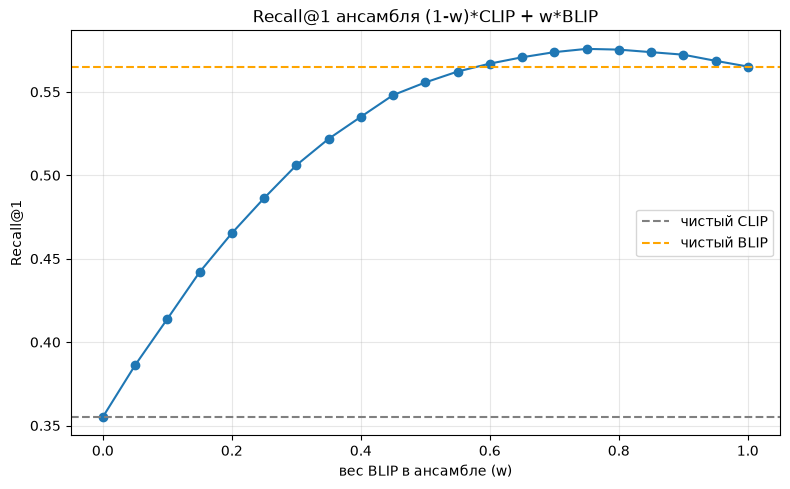

лучший вес w = 0.75 | Recall@1 = 0.5758


In [3]:
def recall_at_k(ranks, k):
    return float(np.mean(ranks <= k))

def all_metrics(ranks):
    return {"Recall@1": recall_at_k(ranks, 1), "Recall@5": recall_at_k(ranks, 5), "Recall@10": recall_at_k(ranks, 10), "Median Rank": float(np.median(ranks)), "Mean Rank": float(np.mean(ranks)), "MRR": float(np.mean(1.0 / ranks))}

recall1_by_w = [recall_at_k(ens_ranks[w], 1) for w in weights]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(weights, recall1_by_w, marker="o")
ax.axhline(recall_at_k(clip_ranks, 1), color="gray", linestyle="--", label="чистый CLIP")
ax.axhline(recall_at_k(blip_ranks, 1), color="orange", linestyle="--", label="чистый BLIP")
ax.set_xlabel("вес BLIP в ансамбле w")
ax.set_ylabel("Recall@1")
ax.set_title("Recall@1 ансамбля (1-w)*CLIP+ w*BLIP")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

best_w = weights[int(np.argmax(recall1_by_w))]
print("лучший вес w =", best_w, "Recall@1 =", round(max(recall1_by_w), 4))

In [4]:
results = pd.DataFrame({"CLIP": all_metrics(clip_ranks), "BLIP-ITM": all_metrics(blip_ranks), f"Ансамбль (w={best_w})": all_metrics(ens_ranks[best_w])})
results.round(4)

,CLIP,BLIP-ITM,Ансамбль (w=0.75)
Recall@1,0.3551,0.5652,0.5758
Recall@5,0.5994,0.8120,0.8187
Recall@10,0.7027,0.8845,0.8882
Median Rank,3.0000,1.0000,1.0000
Mean Rank,23.0430,8.5482,8.2497
MRR,0.4718,0.6757,0.6841


In [5]:
rng = np.random.RandomState(42)
perm = rng.permutation(n_cap)
half1, half2 = perm[:n_cap // 2], perm[n_cap // 2:]

r1_half1 = [recall_at_k(ens_ranks[w][half1], 1) for w in weights]
w_half1 = weights[int(np.argmax(r1_half1))]

print("вес, подобранный на половине 1:", w_half1)
print("Recall@1 на половине 2:", round(recall_at_k(ens_ranks[w_half1][half2], 1), 4))
print("Recall@1 чистого BLIP на половине 2:", round(recall_at_k(blip_ranks[half2], 1), 4))

вес, подобранный на половине 1: 0.8
Recall@1 на половине 2 с этим весом: 0.5731
Recall@1 чистого BLIP на половине 2:   0.5601


## 4. Эксперимент 2

Дальше разбирается, что именно модель не находит.

запросов с ошибкой на топ-1 у BLIP: 10875 из 25010


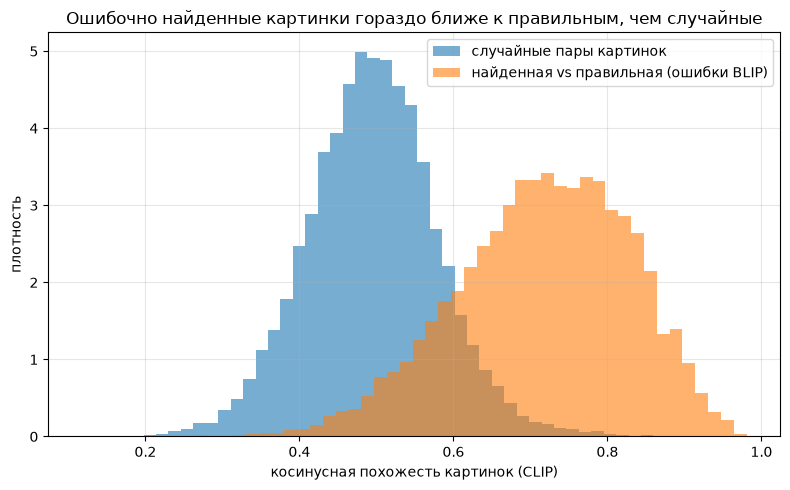

порог похожести (95-й перцентиль случайных пар): 0.632
доля ошибок, где найдена картинка похожее порога: 0.774


In [6]:
fail_mask = blip_ranks > 1
fail_idx = np.where(fail_mask)[0]
print("запросов с ошибкой на топ-1 у BLIP:", len(fail_idx), "из", n_cap)
found_rows = blip_top1[fail_idx]
gt_rows = correct_rows[fail_idx]




error_sims = np.sum(clip_img[found_rows] * clip_img[gt_rows], axis=1)
rng = np.random.RandomState(0)
rand_a = rng.randint(0, n_img, 20000)
rand_b = rng.randint(0, n_img, 20000)
ok = rand_a != rand_b




random_sims = np.sum(clip_img[rand_a[ok]] * clip_img[rand_b[ok]], axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(random_sims, bins=50, alpha=0.6, density=True, label="случайные пары картинок")
ax.hist(error_sims, bins=50, alpha=0.6, density=True, label="найденная vs правильная")
ax.set_xlabel("косинусная похожесть картинок")
ax.set_ylabel("плотность")
ax.set_title("Ошибочно найденные картинки гораздо ближе к правильным, чем случайные")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
threshold = float(np.percentile(random_sims, 95))
share_similar = float(np.mean(error_sims >= threshold))
print("порог похожести:", round(threshold, 3))
print("доля ошибок, где найдена картинка похожее порога:", round(share_similar, 3))

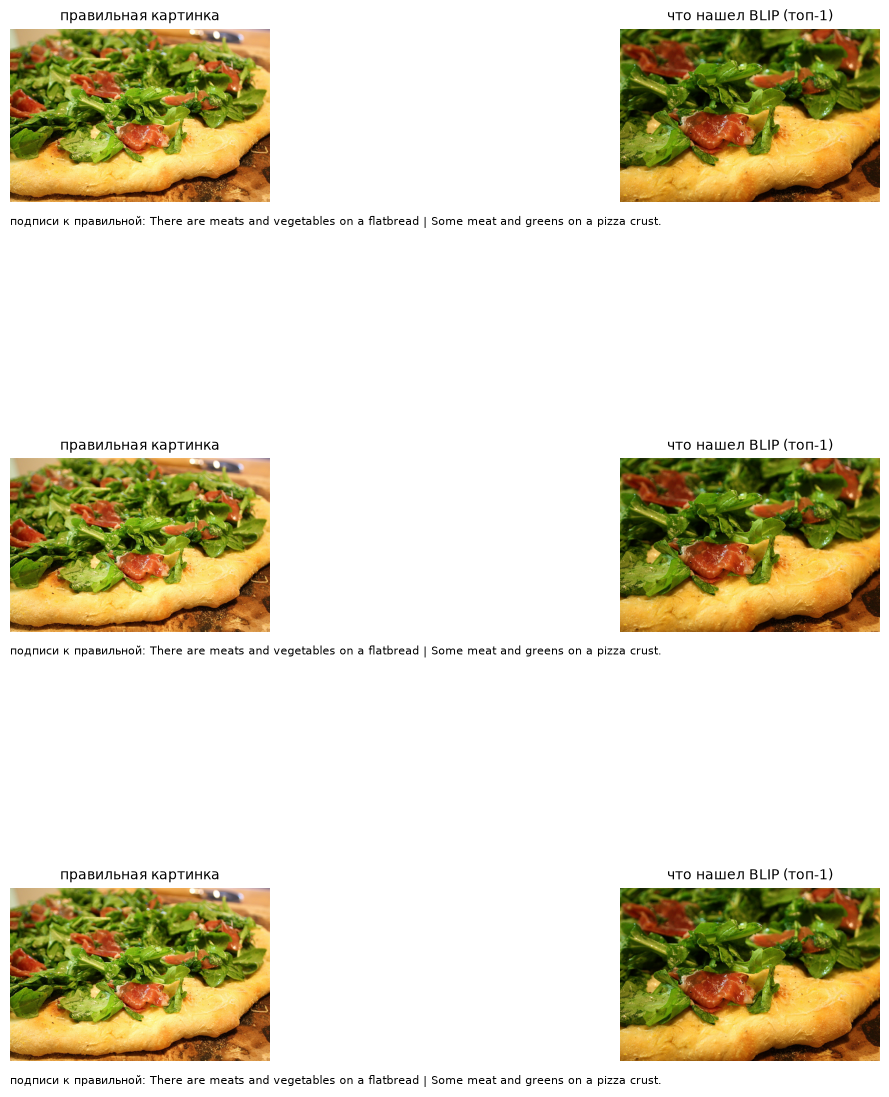

In [7]:
from PIL import Image

id2file = {}
for _, r in caps.drop_duplicates(subset=["image_id"]).iterrows():
    id2file[r["image_id"]] = r["file_name"]
order = np.argsort(-error_sims)
examples = fail_idx[order[:3]]
fig, axes = plt.subplots(len(examples), 2, figsize=(9, 2 * len(examples)))
for i, q in enumerate(examples):
    gt_id = cap_ids[q]
    found_id = img_ids[blip_top1[q]]
    caps_for_img = caps[caps["image_id"] == gt_id]["caption_en"].tolist()
    img_gt = Image.open(img_dir / id2file[gt_id])
    img_found = Image.open(img_dir / id2file[found_id])
    axes[i, 0].imshow(img_gt)
    axes[i, 0].set_title("правильная картинка", fontsize=10)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(img_found)
    axes[i, 1].set_title("топ-1 что нашел BLIP", fontsize=10)
    axes[i, 1].axis("off")
    axes[i, 0].text(0, -0.08, "подписи к правильной: " + " ".join(caps_for_img[:2]),
                    transform=axes[i, 0].transAxes, fontsize=8, va="top", wrap=True)
plt.tight_layout()
plt.show()

## 5. Убирем не соответствующие подписи к фотографиям

In [8]:
clip_pct = pd.Series(clip_self_sim).rank(pct=True).values
blip_pct = pd.Series(blip_self_sim).rank(pct=True).values
suspicion = np.maximum(clip_pct, blip_pct)
rows_list = []
for q in [0.0, 0.05, 0.10, 0.20]:
    keep = suspicion > q
    rows_list.append({"убрано подписей": int((~keep).sum()), "доля убранных": q, "BLIP Recall@1": round(recall_at_k(blip_ranks[keep], 1), 4), "BLIP Recall@5": round(recall_at_k(blip_ranks[keep], 5), 4), "Ансамбль Recall@1": round(recall_at_k(ens_ranks[best_w][keep], 1), 4)})
pd.DataFrame(rows_list).set_index("доля убранных")

,убрано подписей,BLIP Recall@1,BLIP Recall@5,Ансамбль Recall@1
доля убранных,,,,
0.00,0,0.5652,0.8120,0.5758
0.05,383,0.5736,0.8227,0.5844
0.10,892,0.5833,0.8325,0.5945
0.20,2161,0.6051,0.8508,0.6177


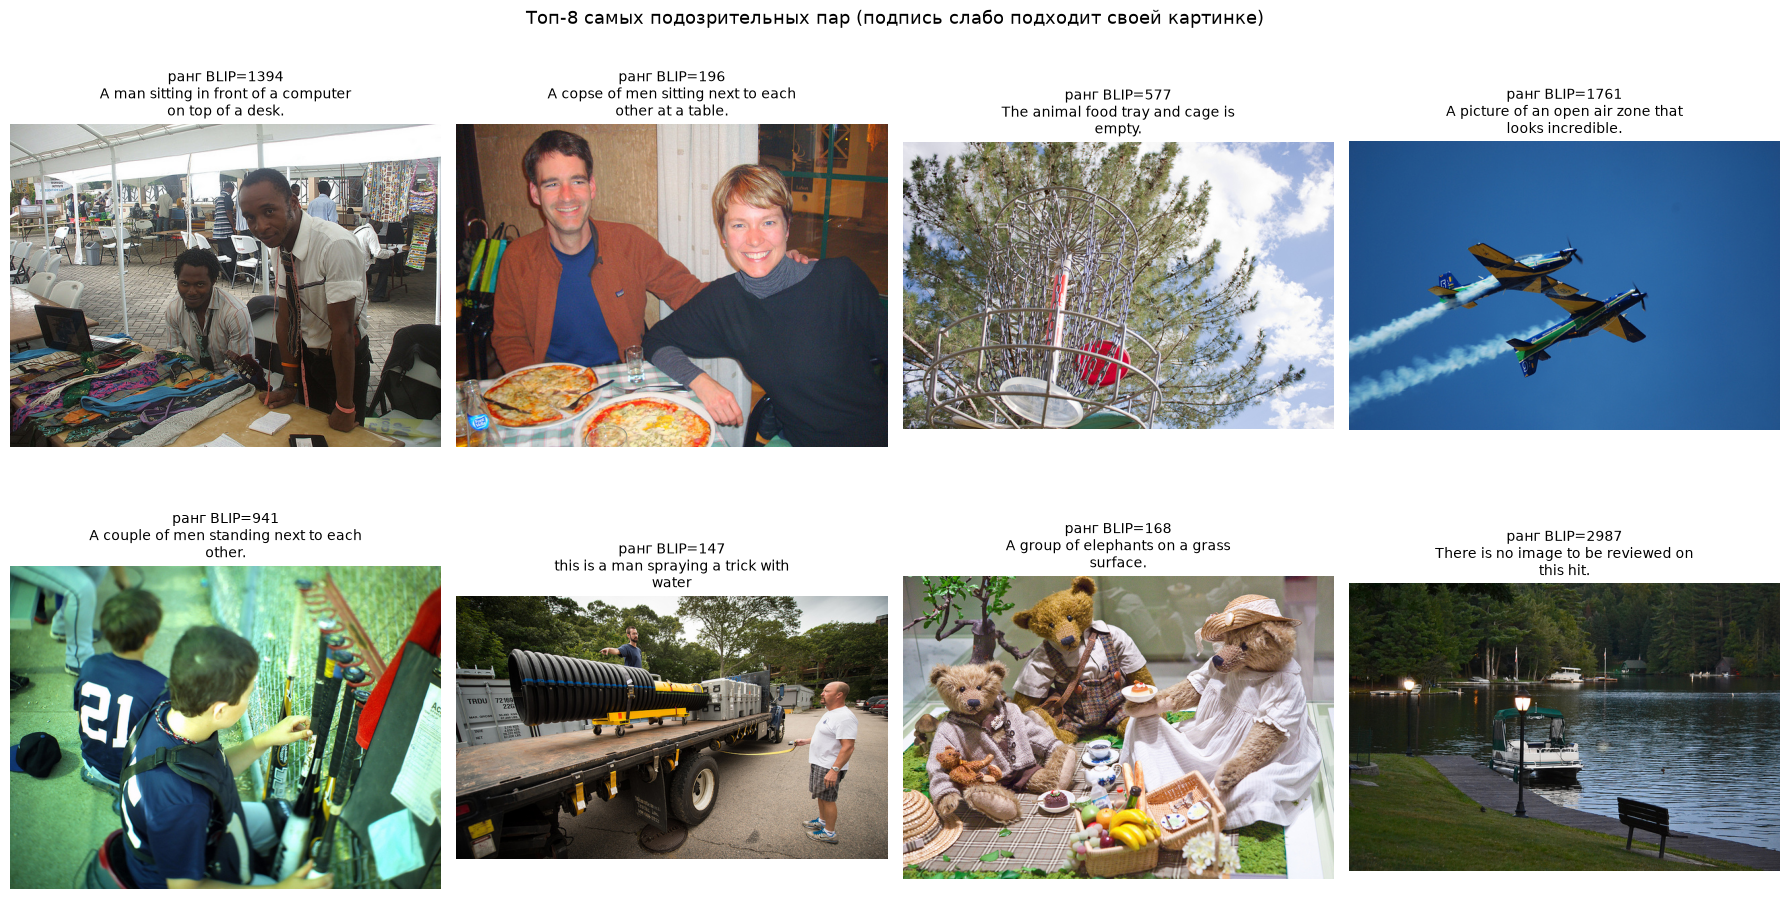

In [9]:
import textwrap

worst = np.argsort(suspicion)[:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, q in zip(axes.ravel(), worst):
    row = caps.iloc[q]
    img = Image.open(img_dir / row["file_name"])
    ax.imshow(img)
    ax.axis("off")
    title = textwrap.fill(row["caption_en"], width=38)
    ax.set_title(f"ранг BLIP={blip_ranks[q]}\n{title}", fontsize=10)
fig.suptitle("Топ-8 самых подозрительных пар", fontsize=13)
plt.tight_layout()
plt.show()